<a href="https://colab.research.google.com/github/Aditya9122002/Retinal-Classification-Model/blob/main/Adamax_0001_NORMDRUSEN_RESNET50_binary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import required libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adamax, Nadam


from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tqdm.keras import TqdmCallback

In [ ]:
# Setting up file paths
train_path = '/content/drive/MyDrive/Binary/NORMDRUSEN/Train'
test_path = '/content/drive/MyDrive/Binary/NORMDRUSEN/Test'
val_path = '/content/drive/MyDrive/Binary/NORMDRUSEN/Val'

In [ ]:
categories = ['DRUSEN', 'NORMAL']

# EDA: Count number of images per category in each set
def count_images_in_directory(directory):
    category_count = {}
    for category in categories:
        category_path = os.path.join(directory, category)
        category_count[category] = len(os.listdir(category_path))
    return category_count

# Get image distribution for train, validation, and test sets
train_distribution = count_images_in_directory(train_path)
test_distribution = count_images_in_directory(test_path)
val_distribution = count_images_in_directory(val_path)

<ipython-input-94-dacdf38d0d92>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(train_distribution.keys()), y=list(train_distribution.values()), palette="Blues")
<ipython-input-94-dacdf38d0d92>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(val_distribution.keys()), y=list(val_distribution.values()), palette="Greens")
<ipython-input-94-dacdf38d0d92>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(test_distribution.keys()), y=list(test_distribution.values()), palette="Reds")


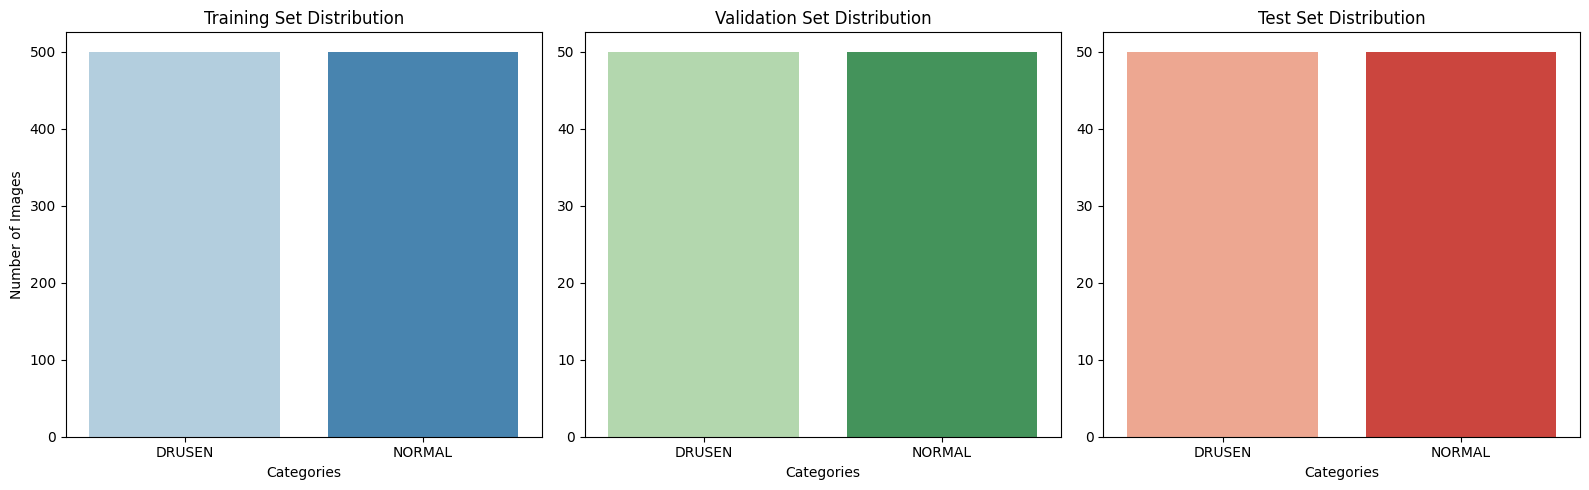

In [ ]:
# Plot the distribution of images across categories for train, validation, and test sets
def plot_class_distribution():
    plt.figure(figsize=(16, 5))

    plt.subplot(1, 3, 1)
    sns.barplot(x=list(train_distribution.keys()), y=list(train_distribution.values()), palette="Blues")
    plt.title("Training Set Distribution")
    plt.xlabel("Categories")
    plt.ylabel("Number of Images")

    plt.subplot(1, 3, 2)
    sns.barplot(x=list(val_distribution.keys()), y=list(val_distribution.values()), palette="Greens")
    plt.title("Validation Set Distribution")
    plt.xlabel("Categories")

    plt.subplot(1, 3, 3)
    sns.barplot(x=list(test_distribution.keys()), y=list(test_distribution.values()), palette="Reds")
    plt.title("Test Set Distribution")
    plt.xlabel("Categories")

    plt.tight_layout()
    plt.show()

# Display class distribution plots
plot_class_distribution()

In [ ]:
# Image preprocessing using ImageDataGenerator
img_size = (224,224)
batch_size = 32

In [ ]:
# Augmentation and rescaling for training set
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=10, width_shift_range=0.2, height_shift_range=0.2, zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Data Generators
train_generator = train_datagen.flow_from_directory(train_path, target_size=img_size, batch_size=batch_size, class_mode='binary')
val_generator = val_datagen.flow_from_directory(val_path, target_size=img_size, batch_size=batch_size, class_mode='binary')
test_generator = test_datagen.flow_from_directory(test_path, target_size=img_size, batch_size=batch_size, class_mode='binary', shuffle=False)

Found 1000 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 100 images belonging to 2 classes.


In [ ]:
# Required Libraries
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Setting up file paths
train_path = '/content/drive/MyDrive/Binary/NORMDRUSEN/Train'
test_path = '/content/drive/MyDrive/Binary/NORMDRUSEN/Test'
val_path = '/content/drive/MyDrive/Binary/NORMDRUSEN/Val'

# Define categories for binary classification
categories = ['DRUSEN', 'NORMAL']

# EDA: Count number of images per category in each set
def count_images_in_directory(directory):
    category_count = {}
    for category in categories:
        category_path = os.path.join(directory, category)
        category_count[category] = len(os.listdir(category_path))
    return category_count

# Get image distribution for train, validation, and test sets
train_distribution = count_images_in_directory(train_path)
val_distribution = count_images_in_directory(val_path)
test_distribution = count_images_in_directory(test_path)

# Print distributions
print("Train Distribution:", train_distribution)
print("Validation Distribution:", val_distribution)
print("Test Distribution:", test_distribution)

# Data Augmentation and Rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Data Generators for Binary Classification
img_size = (224, 224)  # Example target size
batch_size = 32        # Example batch size

# Train Generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

# Validation Generator
val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary'
)

# Test Generator (shuffle set to False for evaluation)
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

# Output distribution
print("Train Generator Classes:", train_generator.class_indices)
print("Validation Generator Classes:", val_generator.class_indices)
print("Test Generator Classes:", test_generator.class_indices)


Train Distribution: {'DRUSEN': 500, 'NORMAL': 500}
Validation Distribution: {'DRUSEN': 50, 'NORMAL': 50}
Test Distribution: {'DRUSEN': 50, 'NORMAL': 50}
Found 1000 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Train Generator Classes: {'DRUSEN': 0, 'NORMAL': 1}
Validation Generator Classes: {'DRUSEN': 0, 'NORMAL': 1}
Test Generator Classes: {'DRUSEN': 0, 'NORMAL': 1}


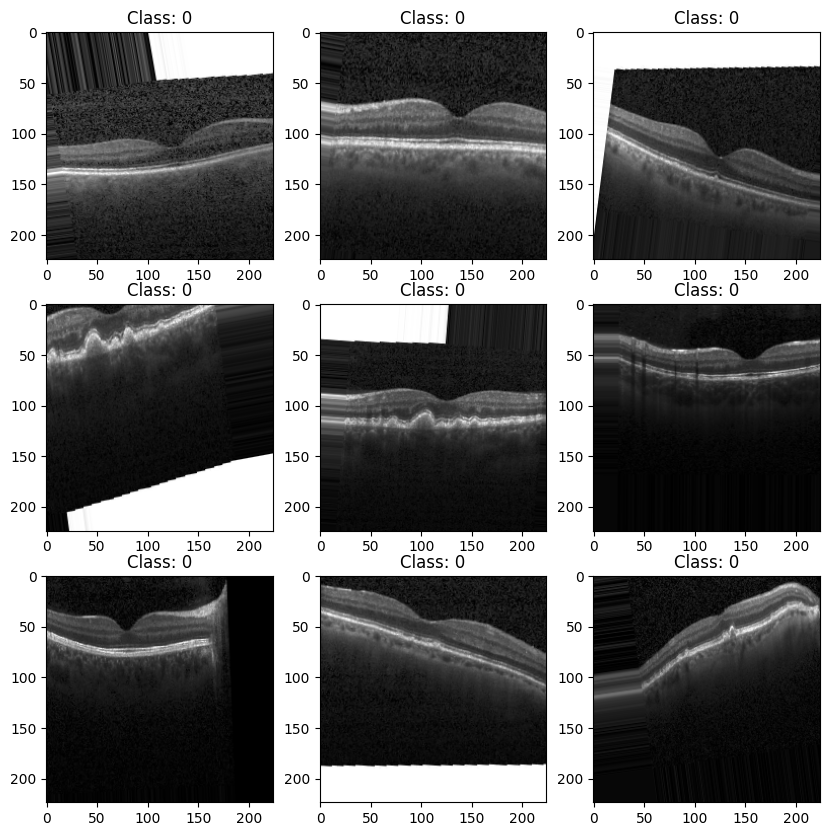

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i])
    plt.title(f"Class: {labels[i].argmax()}")
plt.show()


In [ ]:
from PIL import Image
import os

# Path to the train dataset
train_dir = '/content/drive/MyDrive/Binary/NORMDRUSEN/Train'
first_class_dir = os.path.join(train_dir, os.listdir(train_dir)[0])  # Get the first class folder
sample_image_path = os.path.join(first_class_dir, os.listdir(first_class_dir)[0])  # Get the first image

# Open the image
image = Image.open(sample_image_path)
print(f"Sample Image Size: {image.size}, Mode: {image.mode}")


Sample Image Size: (512, 496), Mode: L


In [ ]:
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

# Function to replicate grayscale images to 3 channels (RGB)
def replicate_grayscale_to_rgb(grayscale_image):
    return np.repeat(grayscale_image, 3, axis=-1)  # Convert (224, 224, 1) to (224, 224, 3)

# Function to create the ResNet model
def create_resnet(input_shape, num_classes):
    # Initialize the ResNet50 model with random weights (no pre-trained weights)
    base_model = ResNet50(weights=None, include_top=False, input_shape=input_shape)

    model = models.Sequential()

    # Add the ResNet50 base model with random weights
    model.add(base_model)

    # Add a Global Average Pooling layer to reduce the spatial dimensions
    model.add(layers.GlobalAveragePooling2D())

    # Add a fully connected layer with 256 units
    model.add(layers.Dense(256, activation='relu'))

    # Add the final output layer for classification (with 'softmax' for multi-class)
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

# Example of processing a grayscale image and converting it to RGB
# Example grayscale image of shape (224, 224, 1)
grayscale_image = np.random.rand(224, 224, 1)  # Example random grayscale image

# Replicate grayscale to RGB (3 channels)
rgb_image = replicate_grayscale_to_rgb(grayscale_image)
print(f"RGB Image Shape: {rgb_image.shape}")  # Should print (224, 224, 3)

# Create the model
input_shape = (224, 224, 3)  # ResNet50 expects RGB images (3 channels)
num_classes = 2  # Number of classes for classification
resnet_model = create_resnet(input_shape, num_classes)

# Compile the model
resnet_model.compile(optimizer=Adamax(), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary to verify architecture
resnet_model.summary()


RGB Image Shape: (224, 224, 3)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             514 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,112,770 (91.98 MB)

 Trainable params: 24,059,650 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
from tensorflow.keras.optimizers import Adamax
optimizer = Adamax(learning_rate=0.0001)
resnet_model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:
pip install tqdm


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping



# Train the model with EarlyStopping
history = resnet_model.fit(
    train_generator,
    epochs=10,
    batch_size=32,
    validation_data=(val_generator),
    callbacks=[TqdmCallback(verbose=1)]  # Add early stopping callback
)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 318s 7s/step - accuracy: 0.5214 - loss: 0.9377 - val_accuracy: 0.5000 - val_loss: 0.6959
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 61s 577ms/step - accuracy: 0.5290 - loss: 0.7416 - val_accuracy: 0.5000 - val_loss: 0.7016
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 557ms/step - accuracy: 0.5564 - loss: 0.7240 - val_accuracy: 0.5000 - val_loss: 0.7075
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 554ms/step - accuracy: 0.5808 - loss: 0.6693 - val_accuracy: 0.5000 - val_loss: 0.7063
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 551ms/step - accuracy: 0.5911 - loss: 0.6806 - val_accuracy: 0.5000 - val_loss: 0.7201
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 566ms/step - accuracy: 0.5791 - loss: 0.7673 - val_accuracy: 0.5000 - val_loss: 0.7290
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 542ms/step - accuracy: 0.5984 - loss: 0.6891 - val_accuracy: 0.5000 - val_loss: 1.0162
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 41s 559ms/step - accuracy: 0.6224 - loss: 0.6699 - val_accuracy: 0.5000 

In [ ]:
test_loss, test_accuracy = resnet_model.evaluate(val_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.4942 - loss: 1.3473
Test Accuracy: 47.00%


In [ ]:
# Predicting on the test set
test_predictions = resnet_model.predict(test_generator)
test_predictions_labels = np.argmax(test_predictions, axis=1)
true_labels = test_generator.classes

4/4 ━━━━━━━━━━━━━━━━━━━━ 33s 8s/step


In [ ]:
# Classification report
class_report = classification_report(true_labels, test_predictions_labels, target_names=categories)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

      DRUSEN       0.47      0.76      0.58        50
      NORMAL       0.40      0.16      0.23        50

    accuracy                           0.46       100
   macro avg       0.44      0.46      0.41       100
weighted avg       0.44      0.46      0.41       100



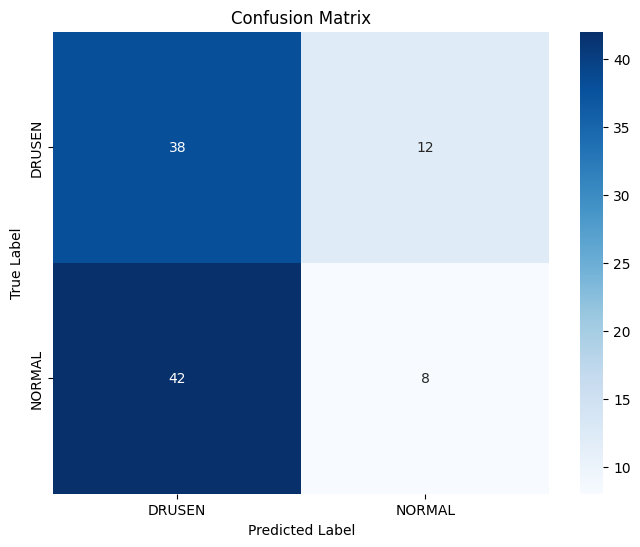

In [ ]:
# Confusion matrix
conf_matrix = confusion_matrix(true_labels, test_predictions_labels)

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="d", xticklabels=categories, yticklabels=categories)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

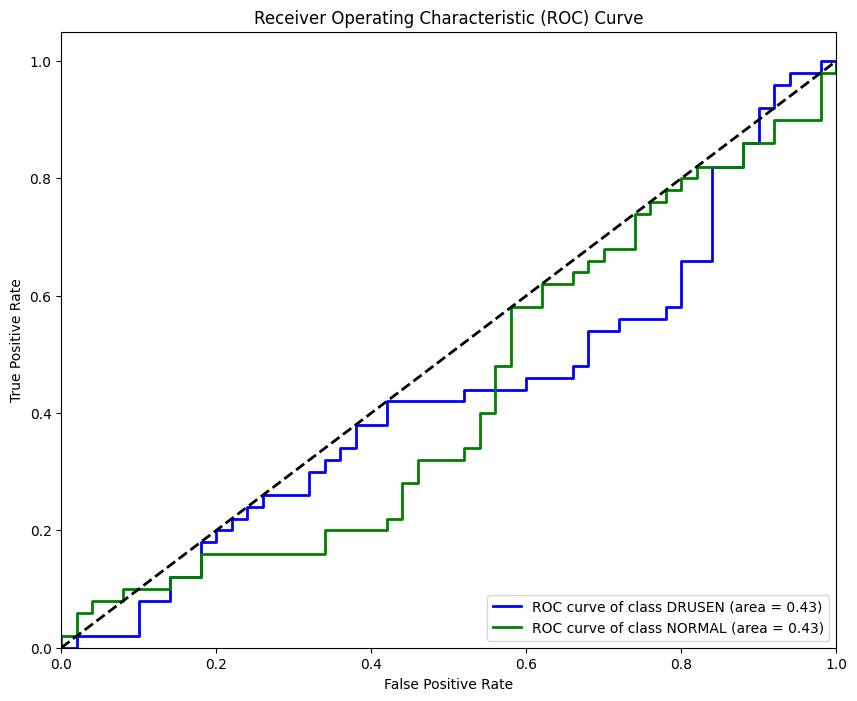

In [ ]:
# ROC Curve for binary-class Classification
def plot_multiclass_roc(test_labels, test_predictions):
    test_labels_binarized = label_binarize(test_labels, classes=[0, 1, 2, 3])
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(len(categories)):
        fpr[i], tpr[i], _ = roc_curve(test_labels_binarized[:, i], test_predictions[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(10, 8))
    for i, color in zip(range(len(categories)), ['blue', 'green', 'orange', 'red']):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'ROC curve of class {categories[i]} (area = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# Plot ROC Curve for binary-class
plot_multiclass_roc(true_labels, test_predictions)

In [ ]:
resnet_model.save('resnet_model.h5')

print("ResNet model trained and saved successfully!")

ResNet model trained and saved successfully!


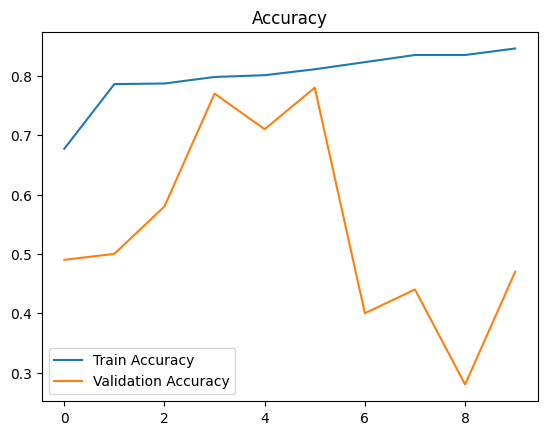

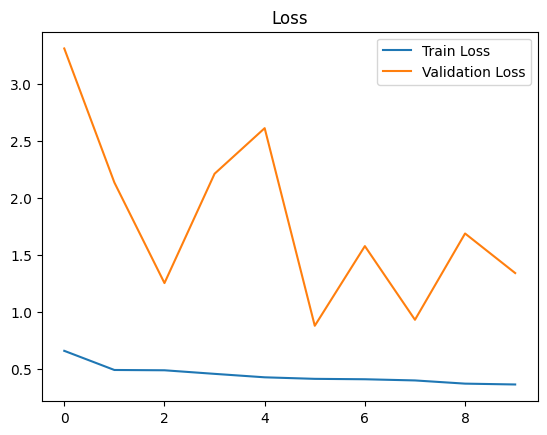

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

# Plot Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')
plt.show()
